# Consolidate the different notebooks into a large one (try to build simple models relating them)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import folium
from folium import plugins
from sodapy import Socrata
import json
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:

# Pick ACS 5-year dataset and year.
CENSUS_YEAR = 2022
CENSUS_DATASET = "acs/acs5"
BASE_URL = f"https://api.census.gov/data/{CENSUS_YEAR}/{CENSUS_DATASET}"

In [ ]:
# Download complete ACS variable metadata so you can browse everything available.
variables_url = f"{BASE_URL}/variables.json"
variables_payload = requests.get(variables_url, timeout=30).json()["variables"]

variables_df = (
    pd.DataFrame.from_dict(variables_payload, orient="index")
    .reset_index()
    .rename(columns={"index": "variable"})
)

for col in ["label", "concept", "predicateType", "group", "limit"]:
    if col not in variables_df.columns:
        variables_df[col] = None

variables_df = variables_df[["variable", "label", "concept", "predicateType", "group", "limit"]]
variables_df = variables_df.sort_values("variable").reset_index(drop=True)

print(f"Total variables in {CENSUS_DATASET} {CENSUS_YEAR}: {len(variables_df):,}")
variables_df.head(25)

In [2]:
# Connect to Chicago Open Data Portal
# Dataset ID: xfya-dxtq (Chicago Air Quality Sensors)
client = Socrata("data.cityofchicago.org", None)

# Fetch data (limit to first 5000 records to start)
# You can increase this or remove limit for full dataset
results = client.get("xfya-dxtq", limit=5000)

# Convert to pandas DataFrame
df = pd.DataFrame.from_records(results)

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Data loaded successfully!
Shape: (5000, 32)

Columns: ['datasourceid', 'time', 'sensor_name', 'pm2_5concmassindividual_raw', 'pm2_5concmassindividual_value', 'pm2_5concnumindividual_raw', 'pm2_5concnumindividual_value', 'relhumidinternalindividual', 'relhumidinternalindividual_1', 'temperatureinternalindividual', 'temperatureinternalindividual_1', 'latitude', 'longitude', 'location', 'record_id', ':@computed_region_rpca_8um6', ':@computed_region_vrxf_vc4k', ':@computed_region_6mkv_f3dw', ':@computed_region_bdys_3d7i', ':@computed_region_8hcu_yrd4', 'no2concindividual_raw', 'no2concindividual_value', 'atmpressureindividual_raw', 'atmpressureindividual_value', 'relhumidambientindividual', 'relhumidambientindividual_1', 'temperatureambientindividual', 'temperatureambientindividual_1', 'winddirectionindividual_raw', 'winddirectionindividual_value', 'windspeedindividual_raw', 'windspeedindividual_value']


## Chicago AQI Hexgrid Comparison with Road Density

Goal:
1. Build one consistent Chicago hexgrid.
2. Compare AQI levels and road-network density in the same hexagons.
3. Explore rush-hour patterns as a commuting proxy.

In [7]:
# Hexgrid + street-network density setup
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Polygon

PLACE_NAME = "Chicago, Illinois, USA"

city_gdf = ox.geocode_to_gdf(PLACE_NAME).to_crs(epsg=26916)
city_poly = city_gdf.geometry.iloc[0]

# Build street network and project to meters.
G_drive = ox.graph_from_place(PLACE_NAME, network_type="drive", simplify=True)
_, edges = ox.graph_to_gdfs(G_drive)
edges_proj = edges.to_crs(city_gdf.crs)

# Build custom hex grid.
hex_radius_m = 1000
hex_width = np.sqrt(3) * hex_radius_m
x_step = hex_width
y_step = 1.5 * hex_radius_m
minx, miny, maxx, maxy = city_poly.bounds

hexes = []
y = miny - 2 * hex_radius_m
row = 0
while y <= maxy + 2 * hex_radius_m:
    x_offset = 0 if row % 2 == 0 else hex_width / 2
    x = minx - 2 * hex_width
    while x <= maxx + 2 * hex_width:
        cx = x + x_offset
        cy = y
        coords = [
            (cx + hex_radius_m * np.cos(theta), cy + hex_radius_m * np.sin(theta))
            for theta in np.linspace(0, 2 * np.pi, 7)[:-1]
        ]
        hexes.append(Polygon(coords))
        x += x_step
    y += y_step
    row += 1

hex_gdf = gpd.GeoDataFrame({"geometry": hexes}, crs=city_gdf.crs)
hex_gdf = gpd.clip(hex_gdf, city_gdf).reset_index(drop=True)

# Drop tiny clipped slivers.
full_hex_area_m2 = (3 * np.sqrt(3) / 2) * (hex_radius_m**2)
hex_gdf["hex_area_m2"] = hex_gdf.geometry.area
hex_gdf = hex_gdf[hex_gdf["hex_area_m2"] >= 0.4 * full_hex_area_m2].copy().reset_index(drop=True)
hex_gdf["hex_id"] = hex_gdf.index
hex_gdf["hex_area_km2"] = hex_gdf["hex_area_m2"] / 1_000_000

# Road density per hex.
street_join = gpd.sjoin(edges_proj[["geometry"]], hex_gdf[["hex_id", "geometry"]], how="inner", predicate="intersects")
street_counts = street_join.groupby("hex_id").size()
hex_gdf["street_count"] = hex_gdf["hex_id"].map(street_counts).fillna(0).astype(int)
hex_gdf["street_density"] = hex_gdf["street_count"] / hex_gdf["hex_area_km2"]

print(f"Hex count: {len(hex_gdf):,}")
hex_gdf[["street_count", "street_density"]].describe()

Hex count: 243


,street_count,street_density
count,243.000000,243.000000
mean,339.041152,139.804106
std,166.842054,63.214227
min,0.000000,0.000000
25%,232.500000,113.948595
50%,375.000000,155.114772
75%,453.000000,178.208783
max,767.000000,295.218438


In [8]:
# AQI sensor assignment to the same hexgrid + time features

aqi_value_candidates = [
    "pm2_5concmassindividual_value",
    "pm2_5concnumindividual_value",
    "no2concindividual_value",
]

aqi_col = next((c for c in aqi_value_candidates if c in df.columns), None)
if aqi_col is None:
    raise ValueError(f"No AQI value column found. Available columns: {list(df.columns)}")

aqi_df = df.copy()
aqi_df[aqi_col] = pd.to_numeric(aqi_df[aqi_col], errors="coerce")
aqi_df["longitude"] = pd.to_numeric(aqi_df["longitude"], errors="coerce")
aqi_df["latitude"] = pd.to_numeric(aqi_df["latitude"], errors="coerce")
aqi_df["time"] = pd.to_datetime(aqi_df["time"], errors="coerce", utc=True)

aqi_df = aqi_df.dropna(subset=[aqi_col, "longitude", "latitude", "time"]).copy()
aq_points = gpd.GeoDataFrame(aqi_df, geometry=gpd.points_from_xy(aqi_df["longitude"], aqi_df["latitude"]), crs="EPSG:4326").to_crs(city_gdf.crs)

aq_join = gpd.sjoin(aq_points, hex_gdf[["hex_id", "geometry"]], how="inner", predicate="within")

# Hour bins for commuting proxy.
aq_join["hour_local"] = aq_join["time"].dt.tz_convert("America/Chicago").dt.hour
aq_join["is_rush"] = aq_join["hour_local"].isin([7, 8, 9, 16, 17, 18])
aq_join["is_offpeak"] = aq_join["hour_local"].isin([1, 2, 3, 4, 11, 12, 13, 14])

# Aggregate AQI by hex.
aqi_hex_mean = aq_join.groupby("hex_id")[aqi_col].mean()
aqi_hex_count = aq_join.groupby("hex_id")[aqi_col].size()
rush_mean = aq_join[aq_join["is_rush"]].groupby("hex_id")[aqi_col].mean()
offpeak_mean = aq_join[aq_join["is_offpeak"]].groupby("hex_id")[aqi_col].mean()

hex_compare = hex_gdf.copy()
hex_compare["aqi_mean"] = hex_compare["hex_id"].map(aqi_hex_mean)
hex_compare["aqi_obs"] = hex_compare["hex_id"].map(aqi_hex_count).fillna(0).astype(int)
hex_compare["aqi_rush_mean"] = hex_compare["hex_id"].map(rush_mean)
hex_compare["aqi_offpeak_mean"] = hex_compare["hex_id"].map(offpeak_mean)
hex_compare["aqi_rush_delta"] = hex_compare["aqi_rush_mean"] - hex_compare["aqi_offpeak_mean"]

print(f"AQI metric used: {aqi_col}")
print(f"Joined AQI points: {len(aq_join):,}")
hex_compare[["aqi_mean", "aqi_rush_delta", "street_density", "aqi_obs"]].describe()

AQI metric used: pm2_5concmassindividual_value
Joined AQI points: 4,747


,aqi_mean,aqi_rush_delta,street_density,aqi_obs
count,210.000000,202.000000,243.000000,243.000000
mean,7.461494,-1.979240,139.804106,19.534979
std,1.201533,2.031361,63.214227,13.818549
min,4.238500,-14.754167,0.000000,0.000000
25%,6.789325,-2.853482,113.948595,13.000000
50%,7.338723,-2.058869,155.114772,18.000000
75%,8.035744,-0.944214,178.208783,25.500000
max,16.725909,5.361667,295.218438,94.000000


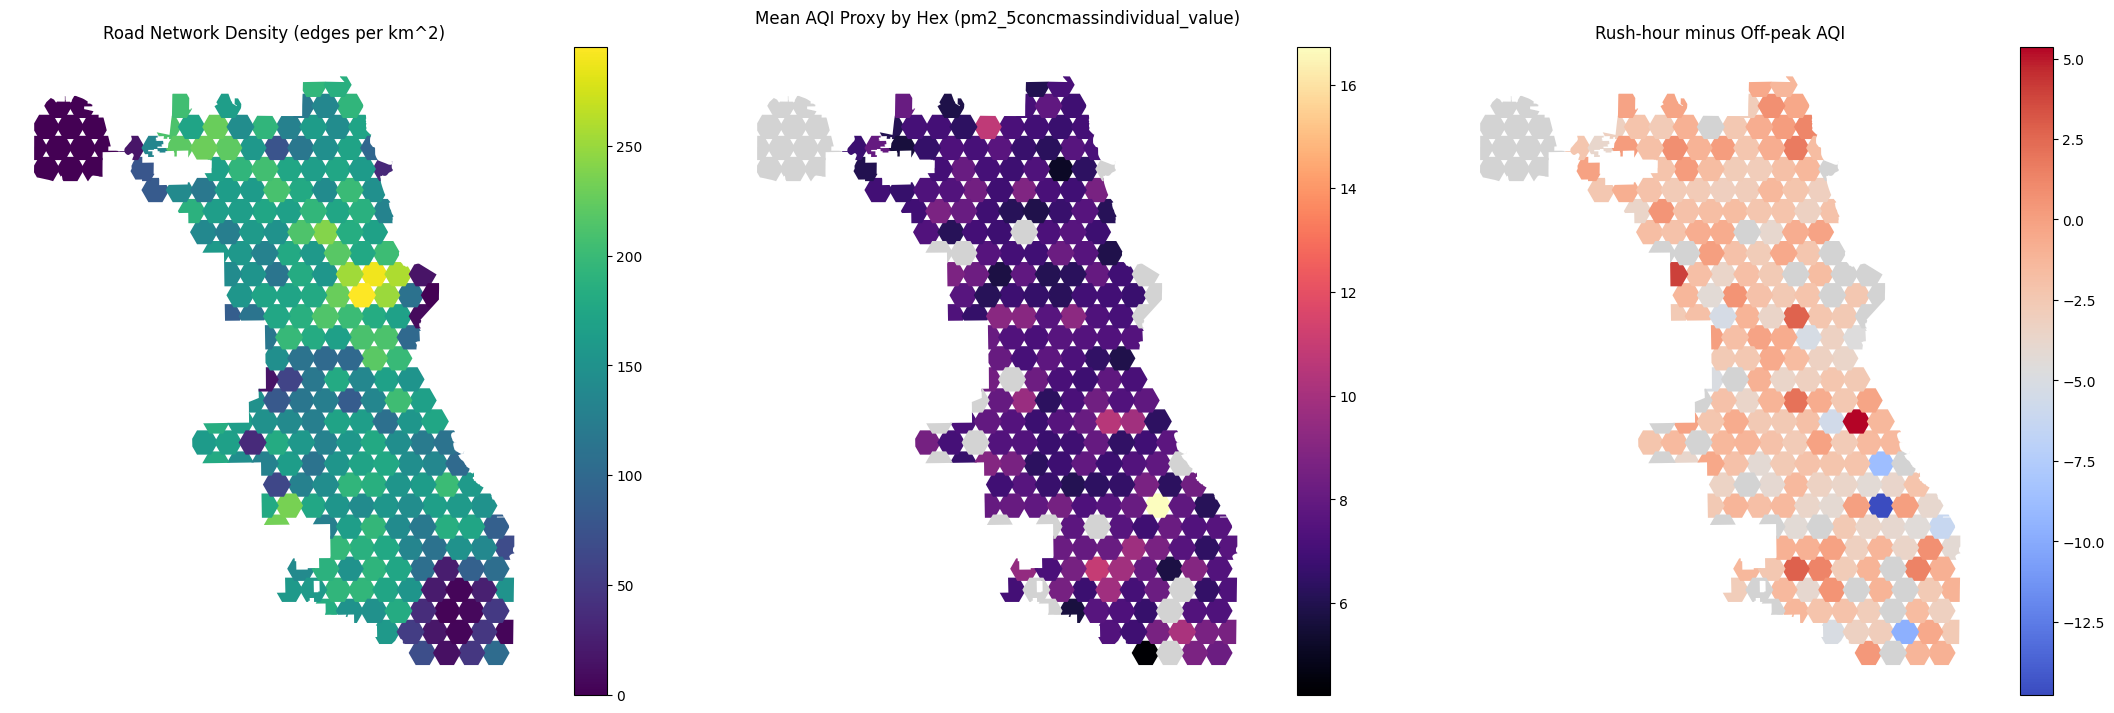

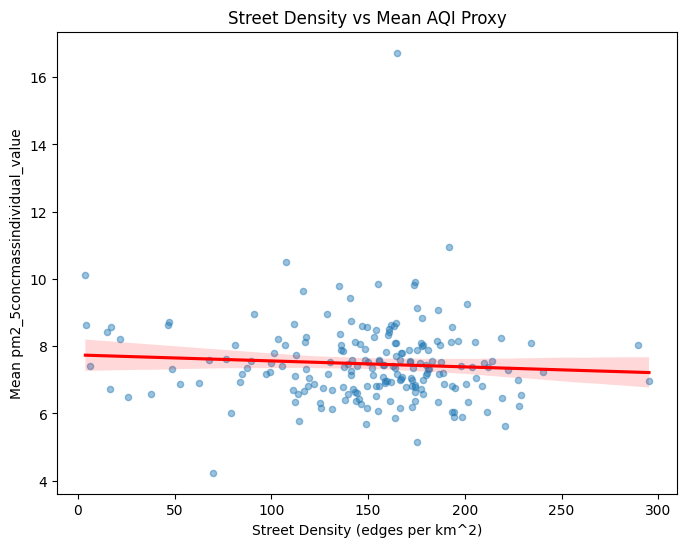

Correlation matrix:
                street_density  aqi_mean  aqi_rush_delta
street_density        1.000000 -0.073706        0.085635
aqi_mean             -0.073706  1.000000       -0.185559
aqi_rush_delta        0.085635 -0.185559        1.000000


,hex_id,aqi_rush_delta,aqi_rush_mean,aqi_offpeak_mean,street_density,aqi_obs
90,90,5.361667,12.903333,7.541667,155.114772,22
173,173,4.004167,12.387500,8.383333,141.136291,12
8,8,2.772000,11.780000,9.008000,149.341270,25
144,144,2.735000,12.835000,10.100000,200.917894,11
34,34,2.125000,7.360000,5.235000,84.678039,23
196,196,1.690000,9.190000,7.500000,171.665480,14
63,63,1.377778,10.817778,9.440000,90.836442,19
7,7,1.280000,9.653333,8.373333,192.065190,20
235,235,1.204000,7.334000,6.130000,172.526177,30
226,226,0.848036,9.064286,8.216250,222.472304,27


In [9]:
# Visual comparison: AQI vs street density + commuting proxy
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

hex_compare.plot(
    column="street_density",
    cmap="viridis",
    legend=True,
    ax=axes[0],
    missing_kwds={"color": "lightgray", "label": "No data"},
)
axes[0].set_title("Road Network Density (edges per km^2)")
axes[0].set_axis_off()

hex_compare.plot(
    column="aqi_mean",
    cmap="magma",
    legend=True,
    ax=axes[1],
    missing_kwds={"color": "lightgray", "label": "No data"},
)
axes[1].set_title(f"Mean AQI Proxy by Hex ({aqi_col})")
axes[1].set_axis_off()

hex_compare.plot(
    column="aqi_rush_delta",
    cmap="coolwarm",
    legend=True,
    ax=axes[2],
    missing_kwds={"color": "lightgray", "label": "No data"},
)
axes[2].set_title("Rush-hour minus Off-peak AQI")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

# Relationship plot: road density vs AQI
compare_df = hex_compare[["street_density", "aqi_mean", "aqi_rush_delta", "aqi_obs"]].dropna().copy()
compare_df = compare_df[compare_df["aqi_obs"] >= 3]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.regplot(data=compare_df, x="street_density", y="aqi_mean", scatter_kws={"alpha": 0.45, "s": 20}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Street Density vs Mean AQI Proxy")
ax.set_xlabel("Street Density (edges per km^2)")
ax.set_ylabel(f"Mean {aqi_col}")
plt.show()

corr = compare_df[["street_density", "aqi_mean", "aqi_rush_delta"]].corr(numeric_only=True)
print("Correlation matrix:")
print(corr)

# Rank potential heavy-commuting hexes by rush-hour AQI increase.
heavy_commute_hexes = hex_compare.sort_values("aqi_rush_delta", ascending=False)[["hex_id", "aqi_rush_delta", "aqi_rush_mean", "aqi_offpeak_mean", "street_density", "aqi_obs"]].head(20)
heavy_commute_hexes

## Daily AQI Hexgrid Slider Comparison

Use two day sliders to compare AQI conditions across dates on the same hex grid.

## NEED TO CHECK IN ON THIS

In [15]:
# Interactive single-day AQI comparison on the same hexgrid
import ipywidgets as widgets
from IPython.display import display

# Build daily AQI aggregates by hex (local Chicago date).
aq_join = aq_join.copy()
aq_join["date_local"] = aq_join["time"].dt.tz_convert("America/Chicago").dt.date

daily_hex = (
    aq_join.groupby(["date_local", "hex_id"])[aqi_col]
    .agg(aqi_mean="mean", aqi_obs="size")
    .reset_index()
)

# Coverage filter: keep only days where >60% of active hexes have values.
active_hex_ids = set(daily_hex["hex_id"].dropna().unique())
active_hex_count = len(active_hex_ids)
if active_hex_count == 0:
    raise ValueError("No active hexes with AQI data were found.")

daily_coverage = (
    daily_hex.groupby("date_local")["hex_id"]
    .nunique()
    .rename("hexes_with_data")
    .reset_index()
)
daily_coverage["coverage_ratio"] = daily_coverage["hexes_with_data"] / active_hex_count

min_coverage = 0.60
eligible_dates = (
    daily_coverage[daily_coverage["coverage_ratio"] > min_coverage]
    .sort_values("date_local")["date_local"]
    .tolist()
)

if len(eligible_dates) < 1:
    raise ValueError(
        "No days meet the >60% coverage rule. "
        "Try increasing the AQI data pull limit or lowering min_coverage."
    )

print(f"Active hexes with AQI data: {active_hex_count}")
print(f"Eligible dates (> {int(min_coverage * 100)}% coverage): {len(eligible_dates)}")


def _day_hex(date_value):
    d = daily_hex[daily_hex["date_local"] == date_value][["hex_id", "aqi_mean", "aqi_obs"]].copy()
    out = hex_gdf[["hex_id", "geometry", "street_density"]].merge(d, on="hex_id", how="left")
    return out


def _zscore(s):
    s_num = pd.to_numeric(s, errors="coerce")
    std = s_num.std(skipna=True)
    if pd.isna(std) or std == 0:
        return s_num * np.nan
    return (s_num - s_num.mean(skipna=True)) / std


def plot_single_day(selected_day, use_zscore=False):
    day_gdf = _day_hex(selected_day).copy()

    # Keep rows with both variables to compute correlation and co-pattern map.
    valid = day_gdf[["street_density", "aqi_mean"]].dropna().copy()
    corr_val = valid["street_density"].corr(valid["aqi_mean"]) if len(valid) > 1 else np.nan

    if use_zscore:
        day_gdf["street_plot"] = _zscore(day_gdf["street_density"])
        day_gdf["aqi_plot"] = _zscore(day_gdf["aqi_mean"])
        day_gdf["copattern"] = day_gdf["street_plot"] * day_gdf["aqi_plot"]
        street_title = "Road Density (z-score)"
        aqi_title = f"AQI by Hex ({aqi_col}, z-score)"
    else:
        day_gdf["street_plot"] = day_gdf["street_density"]
        day_gdf["aqi_plot"] = day_gdf["aqi_mean"]
        # Centered product as a simple local co-variation map in raw mode.
        day_gdf["copattern"] = (
            (day_gdf["street_density"] - day_gdf["street_density"].mean(skipna=True))
            * (day_gdf["aqi_mean"] - day_gdf["aqi_mean"].mean(skipna=True))
        )
        street_title = "Road Density (edges per km^2)"
        aqi_title = f"AQI by Hex ({aqi_col})"

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    day_gdf.plot(
        column="street_plot",
        cmap="viridis",
        legend=True,
        ax=axes[0],
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[0].set_title(street_title)
    axes[0].set_axis_off()

    day_gdf.plot(
        column="aqi_plot",
        cmap="magma",
        legend=True,
        ax=axes[1],
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[1].set_title(f"{aqi_title} | {selected_day}")
    axes[1].set_axis_off()

    vmax = day_gdf["copattern"].abs().quantile(0.95)
    day_gdf.plot(
        column="copattern",
        cmap="coolwarm",
        legend=True,
        ax=axes[2],
        vmin=-vmax if pd.notna(vmax) else None,
        vmax=vmax if pd.notna(vmax) else None,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[2].set_title("Road-AQI Co-pattern Map")
    axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

    print(f"Simple Pearson correlation (road density vs AQI) on {selected_day}: {corr_val:.3f}")
    print(f"Hexes with AQI values on selected day: {int(day_gdf['aqi_obs'].fillna(0).gt(0).sum()):,}")


# Controls: one day slider + z-score toggle with live updates.
day_slider = widgets.SelectionSlider(
    options=eligible_dates,
    value=eligible_dates[-1],
    description="Day",
    continuous_update=False,
    layout=widgets.Layout(width="95%"),
)

scale_buttons = widgets.ToggleButtons(
    options=[("Raw", False), ("Z-score", True)],
    value=False,
    description="Scale",
)

ui = widgets.VBox([day_slider, scale_buttons])
out = widgets.interactive_output(
    plot_single_day,
    {"selected_day": day_slider, "use_zscore": scale_buttons},
)
display(ui, out)

Active hexes with AQI data: 210
Eligible dates (> 60% coverage): 7


Output()

In [32]:
# Build hex-level Census features and fixed AQI metrics for Chicago
import requests

# 1) Fixed AQI summaries by hex over the full time span in aq_join
aqi_fixed_hex = (
    aq_join.groupby("hex_id")[aqi_col]
    .agg(aqi_mean_duration="mean", aqi_std_duration="std", aqi_obs_duration="size")
    .reset_index()
)

# 2) Pull Census tract attributes (same core factors tracked in ChicagoCensus.ipynb)
CENSUS_YEAR_HEX = 2022
CENSUS_BASE = f"https://api.census.gov/data/{CENSUS_YEAR_HEX}/acs/acs5"
CENSUS_VARS = {
    "B01003_001E": "population",
    "B02001_002E": "white_pop",
    "B02001_003E": "black_pop",
    "B02001_005E": "asian_pop",
    "B19013_001E": "median_hh_income",
}

params = {
    "get": "NAME," + ",".join(CENSUS_VARS.keys()),
    "for": "tract:*",
    "in": "state:17 county:031",
}
resp = requests.get(CENSUS_BASE, params=params, timeout=60)
resp.raise_for_status()
raw = resp.json()
cook_tracts_df = pd.DataFrame(raw[1:], columns=raw[0])
cook_tracts_df["tract"] = cook_tracts_df["tract"].astype(str).str.zfill(6)

for code, nice in CENSUS_VARS.items():
    cook_tracts_df[nice] = pd.to_numeric(cook_tracts_df[code], errors="coerce")

# Census negative sentinel for missing income
cook_tracts_df.loc[cook_tracts_df["median_hh_income"] < 0, "median_hh_income"] = pd.NA

# Tract geometry for Cook county + Chicago boundary filter
tract_url = "https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_17_tract.zip"
place_url = "https://www2.census.gov/geo/tiger/TIGER2022/PLACE/tl_2022_17_place.zip"

il_tracts = gpd.read_file(tract_url)
cook_tract_geoms = il_tracts[il_tracts["COUNTYFP"] == "031"].copy()
cook_tract_geoms["ALAND"] = pd.to_numeric(cook_tract_geoms["ALAND"], errors="coerce")
cook_tract_geoms = cook_tract_geoms[cook_tract_geoms["ALAND"] > 0].copy()

il_places = gpd.read_file(place_url)
chicago_boundary = il_places[il_places["PLACEFP"] == "14000"][["geometry"]].copy()

chicago_tract_geoms = gpd.sjoin(cook_tract_geoms, chicago_boundary, how="inner", predicate="intersects")
chicago_tract_geoms["tract"] = chicago_tract_geoms["TRACTCE"].astype(str).str.zfill(6)

chicago_tracts = chicago_tract_geoms[["tract", "geometry"]].merge(
    cook_tracts_df[["tract"] + list(CENSUS_VARS.values())],
    on="tract",
    how="left",
)

# Derived Census composition features at tract level
chicago_tracts["white_share_tract"] = chicago_tracts["white_pop"] / chicago_tracts["population"]
chicago_tracts["black_share_tract"] = chicago_tracts["black_pop"] / chicago_tracts["population"]
chicago_tracts["asian_share_tract"] = chicago_tracts["asian_pop"] / chicago_tracts["population"]

# 3) Spatially allocate tract factors to hexes
chicago_tracts = chicago_tracts.to_crs(hex_gdf.crs)
chicago_tracts["tract_area_m2"] = chicago_tracts.geometry.area

hex_core = hex_gdf[["hex_id", "hex_area_km2", "street_density", "geometry"]].copy()
intersections = gpd.overlay(
    chicago_tracts,
    hex_core[["hex_id", "geometry"]],
    how="intersection",
)
intersections["inter_area_m2"] = intersections.geometry.area
intersections = intersections[intersections["inter_area_m2"] > 0].copy()

# Areal allocation for counts
intersections["pop_piece"] = intersections["population"] * (intersections["inter_area_m2"] / intersections["tract_area_m2"])
intersections["white_piece"] = intersections["white_pop"] * (intersections["inter_area_m2"] / intersections["tract_area_m2"])
intersections["black_piece"] = intersections["black_pop"] * (intersections["inter_area_m2"] / intersections["tract_area_m2"])
intersections["asian_piece"] = intersections["asian_pop"] * (intersections["inter_area_m2"] / intersections["tract_area_m2"])

# Area-weighted means for intensive features
intersections["income_weighted_piece"] = intersections["median_hh_income"] * intersections["inter_area_m2"]

hex_census = intersections.groupby("hex_id", as_index=False).agg(
    pop_est=("pop_piece", "sum"),
    white_est=("white_piece", "sum"),
    black_est=("black_piece", "sum"),
    asian_est=("asian_piece", "sum"),
    income_weighted_sum=("income_weighted_piece", "sum"),
    inter_area_sum=("inter_area_m2", "sum"),
)

hex_census["white_share"] = hex_census["white_est"] / hex_census["pop_est"]
hex_census["black_share"] = hex_census["black_est"] / hex_census["pop_est"]
hex_census["asian_share"] = hex_census["asian_est"] / hex_census["pop_est"]
hex_census["median_income_aw"] = hex_census["income_weighted_sum"] / hex_census["inter_area_sum"]

chicago_hex_census_compare = (
    hex_core.merge(hex_census, on="hex_id", how="left")
    .merge(aqi_fixed_hex, on="hex_id", how="left")
)
chicago_hex_census_compare["pop_density_est"] = chicago_hex_census_compare["pop_est"] / chicago_hex_census_compare["hex_area_km2"]

# Keep only plausible nonnegative AQI variability
chicago_hex_census_compare.loc[chicago_hex_census_compare["aqi_std_duration"] < 0, "aqi_std_duration"] = np.nan

print(f"Hex rows in merged Chicago table: {len(chicago_hex_census_compare):,}")
print(f"Hexes with AQI mean available: {int(chicago_hex_census_compare['aqi_mean_duration'].notna().sum()):,}")
print(f"Hexes with AQI std available: {int(chicago_hex_census_compare['aqi_std_duration'].notna().sum()):,}")

chicago_hex_census_compare[[
    "street_density",
    "aqi_mean_duration",
    "aqi_std_duration",
    "pop_density_est",
    "white_share",
    "black_share",
    "asian_share",
    "median_income_aw",
]].describe()

Hex rows in merged Chicago table: 243
Hexes with AQI mean available: 210
Hexes with AQI std available: 208


,street_density,aqi_mean_duration,aqi_std_duration,pop_density_est,white_share,black_share,asian_share,median_income_aw
count,243.000000,210.000000,208.000000,242.000000,238.000000,238.000000,238.000000,242.000000
mean,139.804106,7.461494,2.818019,4433.230884,0.383136,0.345675,0.057947,67868.153745
std,63.214227,1.201533,1.498842,2888.441109,0.266359,0.366382,0.083953,36957.184263
min,0.000000,4.238500,0.306159,0.000000,0.001211,0.000157,0.000000,0.000000
25%,113.948595,6.789325,1.989081,2595.311136,0.111582,0.032080,0.005033,41763.562897
50%,155.114772,7.338723,2.356377,4093.561136,0.382770,0.136208,0.019249,59703.965525
75%,178.208783,8.035744,3.354116,6055.401539,0.602099,0.713820,0.077116,88351.283041
max,295.218438,16.725909,12.548118,16723.954554,0.915323,0.981114,0.526331,169321.602634


Correlation of Census factors with road density and AQI fixed metrics:
                  street_density  aqi_mean_duration  aqi_std_duration
pop_density_est            0.583             -0.201            -0.216
median_income_aw           0.478             -0.131            -0.163
white_share                0.076             -0.196            -0.205
black_share                0.014              0.195             0.239
asian_share                0.059             -0.151            -0.087


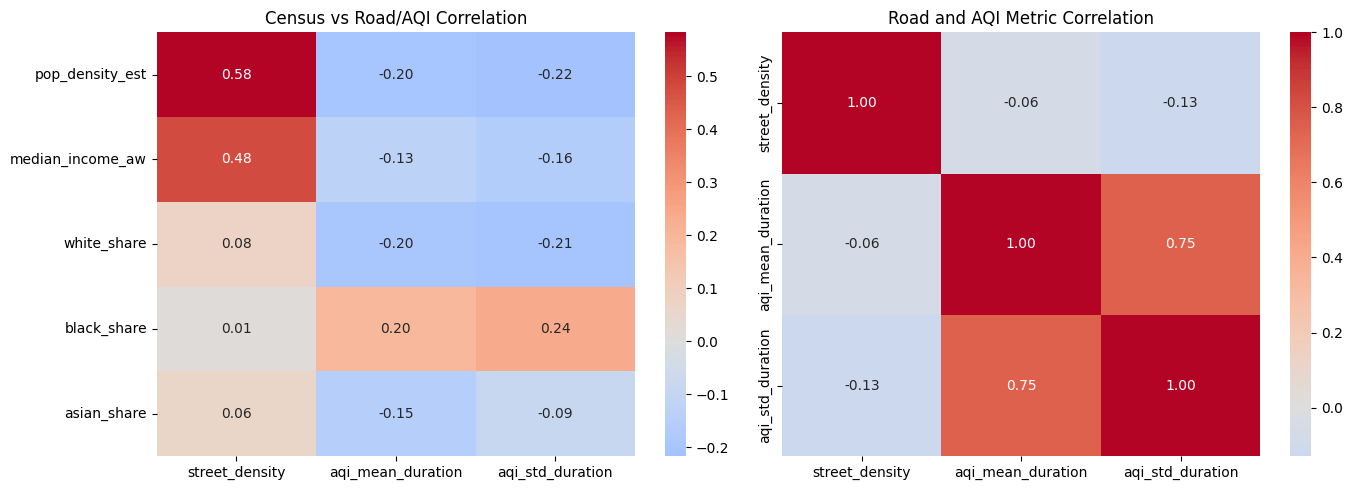

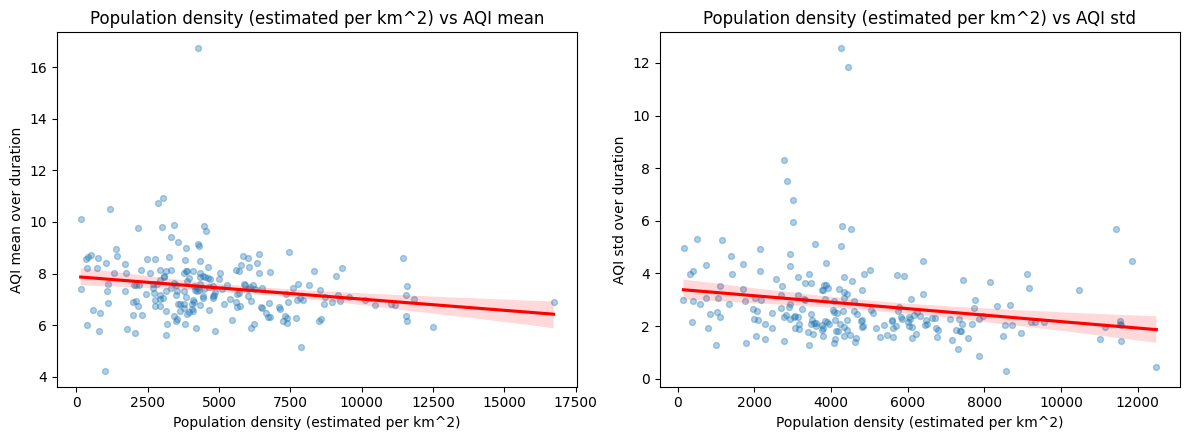

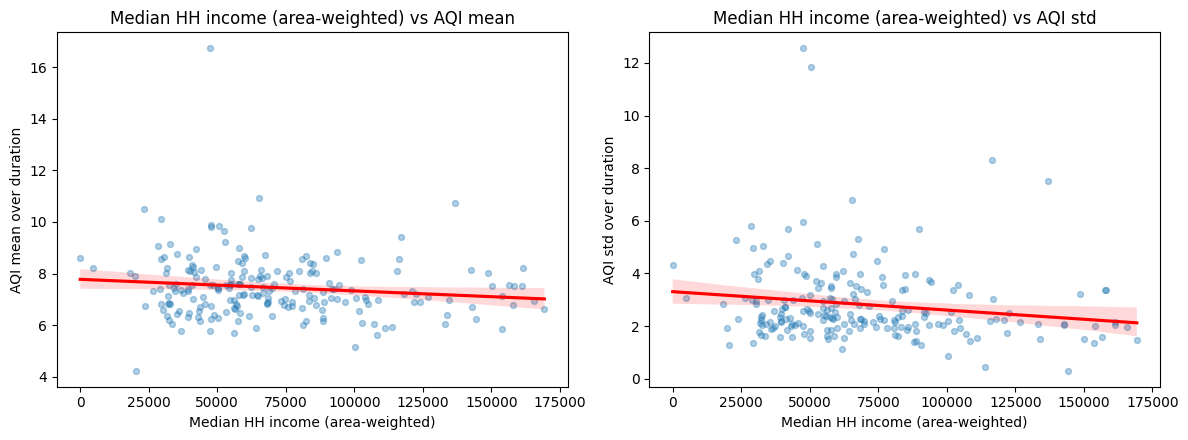

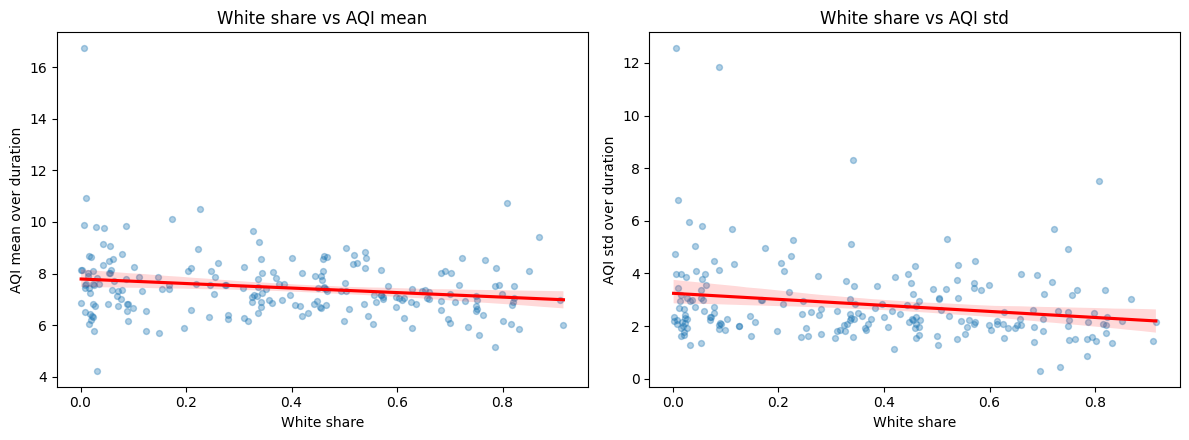

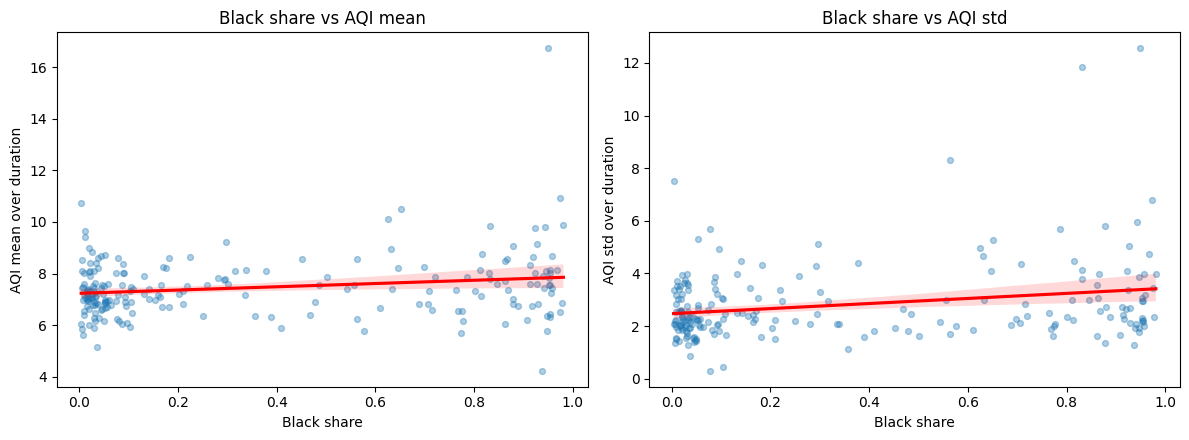

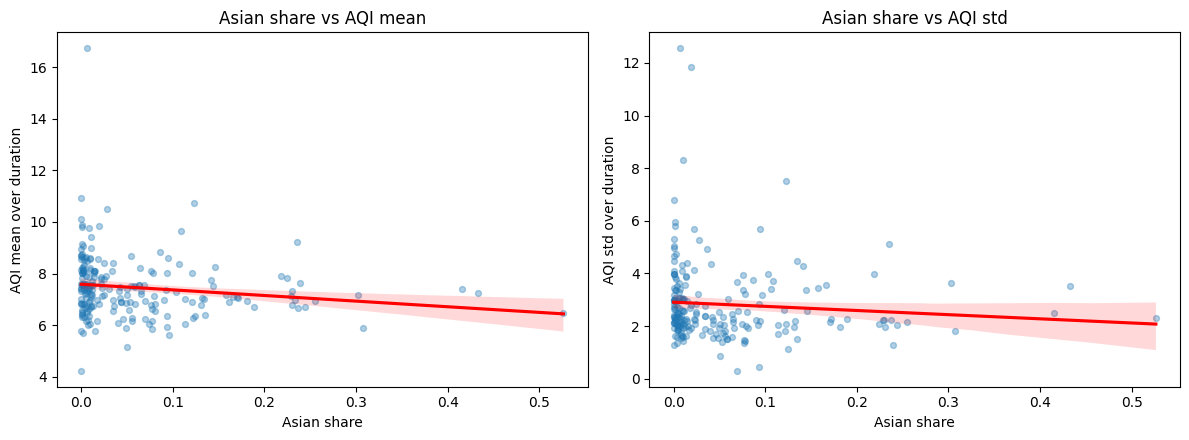

,hex_id,street_density,aqi_mean_duration,aqi_std_duration,pop_density_est,median_income_aw,white_share,black_share,asian_share
0,0,158.615338,6.970833,1.431188,2761.584632,108638.621350,0.909301,0.015505,0.009880
1,1,140.613758,9.435000,3.018217,3305.335237,116956.466194,0.868758,0.011926,0.011138
2,2,182.777819,NaN,NaN,2356.447671,81321.975442,0.507947,0.356566,0.011010
3,3,148.766724,5.697826,1.606648,2050.549683,56178.911549,0.148093,0.773272,0.001605
4,4,194.759491,6.756667,2.345042,2764.476008,57241.663828,0.071090,0.888086,0.005981


In [33]:
# Analyze relationships: Census factors vs road density and fixed AQI metrics
analysis_cols = [
    "street_density",
    "aqi_mean_duration",
    "aqi_std_duration",
    "pop_density_est",
    "median_income_aw",
    "white_share",
    "black_share",
    "asian_share",
]

analysis_df = chicago_hex_census_compare[analysis_cols].copy()

# Correlation matrix (pairwise complete observations)
corr_all = analysis_df.corr(numeric_only=True)
focus_rows = ["pop_density_est", "median_income_aw", "white_share", "black_share", "asian_share"]
focus_cols = ["street_density", "aqi_mean_duration", "aqi_std_duration"]
corr_focus = corr_all.loc[focus_rows, focus_cols]

print("Correlation of Census factors with road density and AQI fixed metrics:")
print(corr_focus.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_focus, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Census vs Road/AQI Correlation")

sns.heatmap(
    corr_all.loc[["street_density", "aqi_mean_duration", "aqi_std_duration"], ["street_density", "aqi_mean_duration", "aqi_std_duration"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Road and AQI Metric Correlation")
plt.tight_layout()
plt.show()

# Scatter panel: each Census factor against both AQI summaries
plot_factors = [
    ("pop_density_est", "Population density (estimated per km^2)"),
    ("median_income_aw", "Median HH income (area-weighted)"),
    ("white_share", "White share"),
    ("black_share", "Black share"),
    ("asian_share", "Asian share"),
]

for factor_col, factor_label in plot_factors:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    d_mean = chicago_hex_census_compare[[factor_col, "aqi_mean_duration"]].dropna()
    sns.regplot(
        data=d_mean,
        x=factor_col,
        y="aqi_mean_duration",
        scatter_kws={"alpha": 0.35, "s": 18},
        line_kws={"color": "red"},
        ax=axes[0],
    )
    axes[0].set_title(f"{factor_label} vs AQI mean")
    axes[0].set_xlabel(factor_label)
    axes[0].set_ylabel("AQI mean over duration")

    d_std = chicago_hex_census_compare[[factor_col, "aqi_std_duration"]].dropna()
    sns.regplot(
        data=d_std,
        x=factor_col,
        y="aqi_std_duration",
        scatter_kws={"alpha": 0.35, "s": 18},
        line_kws={"color": "red"},
        ax=axes[1],
    )
    axes[1].set_title(f"{factor_label} vs AQI std")
    axes[1].set_xlabel(factor_label)
    axes[1].set_ylabel("AQI std over duration")

    plt.tight_layout()
    plt.show()

# Optional preview table for downstream modeling
chicago_hex_census_compare[[
    "hex_id", "street_density", "aqi_mean_duration", "aqi_std_duration",
    "pop_density_est", "median_income_aw", "white_share", "black_share", "asian_share"
]].head()

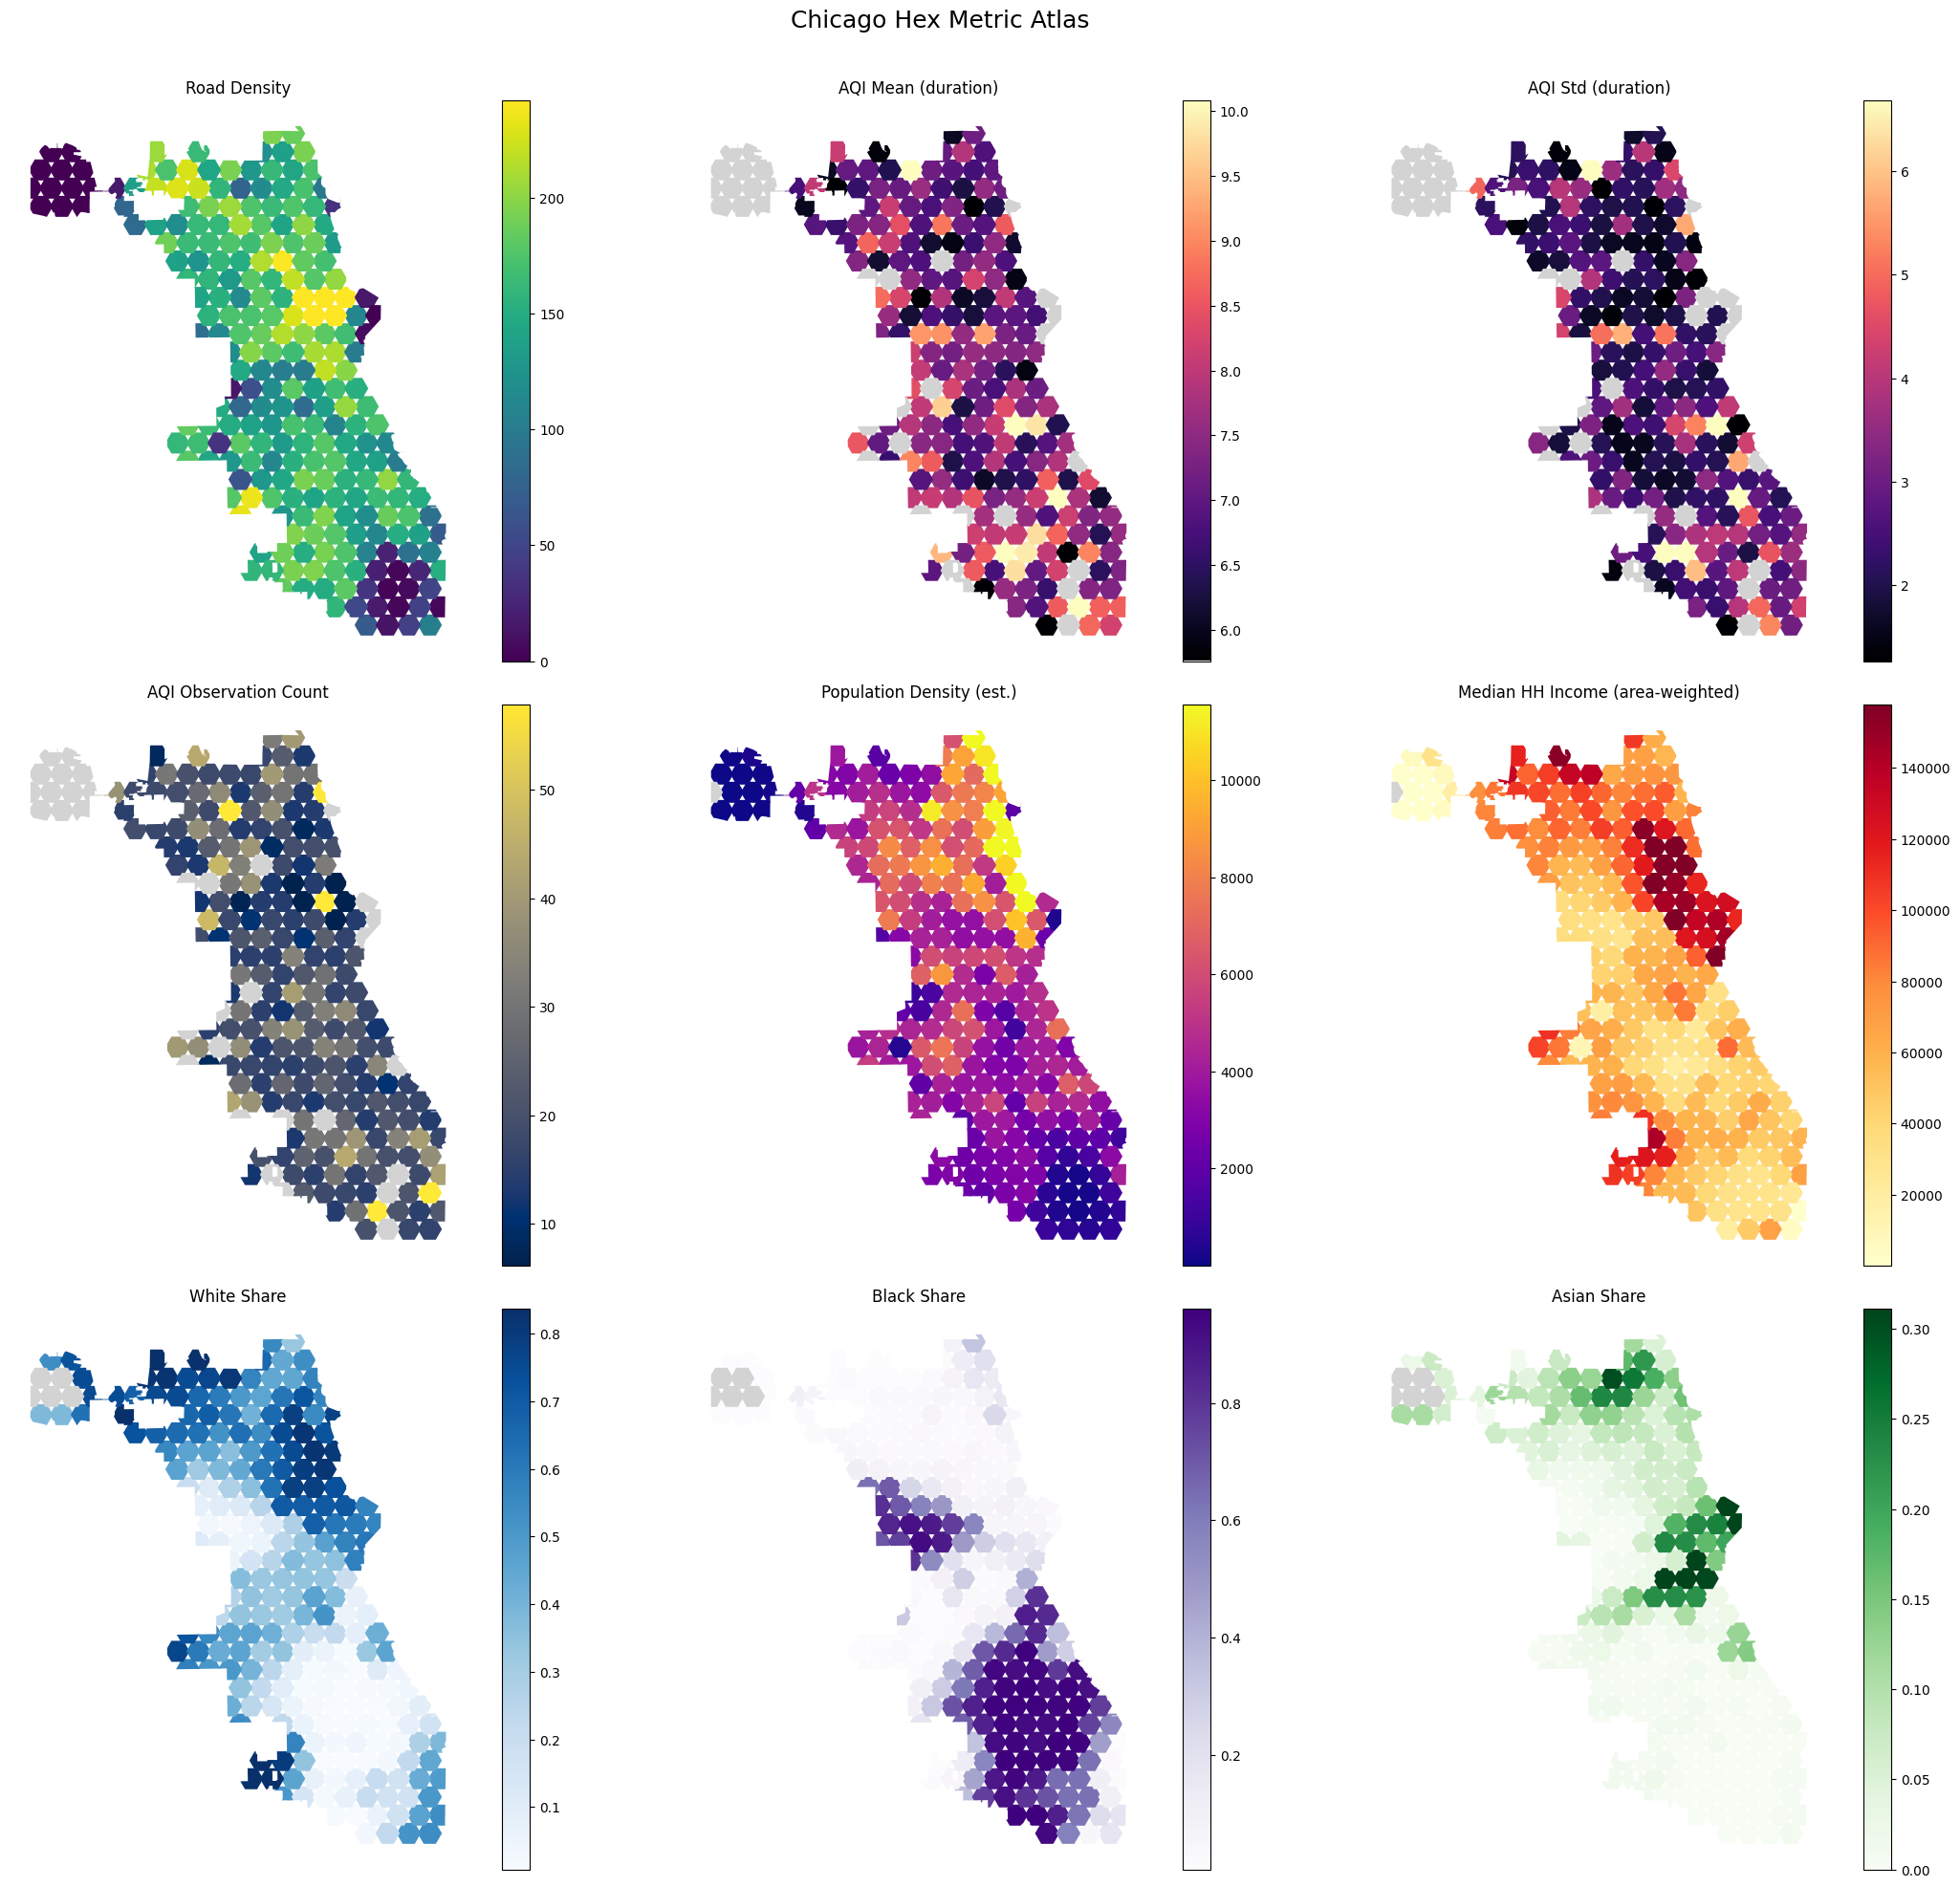

In [34]:
# Big grid: all Chicago hex metrics in one atlas-style figure
hex_plot_specs = [
    ("street_density", "Road Density", "viridis"),
    ("aqi_mean_duration", "AQI Mean (duration)", "magma"),
    ("aqi_std_duration", "AQI Std (duration)", "magma"),
    ("aqi_obs_duration", "AQI Observation Count", "cividis"),
    ("pop_density_est", "Population Density (est.)", "plasma"),
    ("median_income_aw", "Median HH Income (area-weighted)", "YlOrRd"),
    ("white_share", "White Share", "Blues"),
    ("black_share", "Black Share", "Purples"),
    ("asian_share", "Asian Share", "Greens"),
]

plot_df = chicago_hex_census_compare.copy()

ncols = 3
nrows = int(np.ceil(len(hex_plot_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 6.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, (col, title, cmap) in enumerate(hex_plot_specs):
    ax = axes[i]
    col_data = pd.to_numeric(plot_df[col], errors="coerce")

    # Quantile clipping keeps extreme outliers from flattening map contrast.
    if col_data.notna().sum() > 10:
        vmin = col_data.quantile(0.02)
        vmax = col_data.quantile(0.98)
        if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
            vmin, vmax = None, None
    else:
        vmin, vmax = None, None

    plot_df.plot(
        column=col,
        cmap=cmap,
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    ax.set_title(title)
    ax.set_axis_off()

# Hide unused panels, if any.
for j in range(len(hex_plot_specs), len(axes)):
    axes[j].axis("off")

plt.suptitle("Chicago Hex Metric Atlas", y=1.01, fontsize=18)
plt.tight_layout()
plt.show()

## Chicago Hex + Census Factor Comparison

This section links Chicago Census tract factors to the same Chicago hexes used for road density and AQI.

Fixed AQI measures used per hex:
1. Mean AQI over the full pulled duration.
2. AQI standard deviation over the full pulled duration.

## Chicago Open Data Column Discovery (Schools, Food Inspections, 311 Pot Holes)

This section only inspects schemas so we can choose variables before integrating them into hex analysis.

In [38]:
# Direct column discovery for requested Chicago datasets with local fallback
from pathlib import Path
import re
from sodapy import Socrata

DOMAIN = "data.cityofchicago.org"
client = Socrata(DOMAIN, None)

TARGET_DATASETS = {
    "Chicago Public Schools - School Profile Information SY2425": "3dhs-m3w4",
    "Food Inspections": "4ijn-s7e5",
    "311 Service Requests - Pot Holes Reported - Historical": "7as2-ds3y",
}


def _columns_from_local_notebook(dataset_name):
    nb_path = Path("c:/Users/Tyler Marino/OneDrive/Desktop/EOData/SensorNetwork/notebooks/ChicagoOpenData.ipynb")
    if not nb_path.exists():
        return []

    txt = nb_path.read_text(encoding="utf-8", errors="ignore")
    esc = re.escape(f"'{dataset_name}': [")

    # Prefer bounded capture to the next dataset key, then fallback to first closing bracket.
    pattern = re.compile(rf"(?s){esc}(.*?)\],\s*\r?\n\s*'", re.MULTILINE)
    m = pattern.search(txt)
    if not m:
        pattern2 = re.compile(rf"(?s){esc}(.*?)\]", re.MULTILINE)
        m = pattern2.search(txt)
    if not m:
        return []

    cols = re.findall(r"'([^']+)'", m.group(1))
    out = []
    seen = set()
    for c in cols:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out


schema_rows = []
for ds_name, ds_id in TARGET_DATASETS.items():
    print("\n" + "=" * 90)
    print(f"Dataset: {ds_name}")
    print(f"Dataset ID: {ds_id}")

    columns = []
    source = "live API"

    try:
        sample = client.get(ds_id, limit=5)
        if sample:
            columns = sorted({k for row in sample for k in row.keys()})
    except Exception:
        columns = []

    if not columns:
        source = "local ChicagoOpenData notebook"
        columns = _columns_from_local_notebook(ds_name)

    print(f"Column source: {source}")
    print(f"Column count: {len(columns)}")
    print("Columns:")
    print(columns)

    # Quick helper metric for Food Inspections if score exists and API is available.
    if ds_name.lower().startswith("food inspections"):
        if "score" in columns:
            try:
                agg = client.get(ds_id, select="avg(score) as avg_score, count(*) as n_rows", limit=1)
                if agg:
                    print(f"Food Inspections average score: {agg[0].get('avg_score')}")
                    print(f"Food Inspections total rows: {agg[0].get('n_rows')}")
            except Exception as e:
                print(f"Could not compute Food Inspections avg score from live API: {e}")
        else:
            print("No 'score' column found in current schema snapshot.")

    schema_rows.append({
        "dataset": ds_name,
        "dataset_id": ds_id,
        "n_columns": len(columns),
        "column_source": source,
        "has_score_column": ("score" in [c.lower() for c in columns]),
    })

schema_discovery_summary = pd.DataFrame(schema_rows)
print("\nSummary:")
display(schema_discovery_summary)


Dataset: Chicago Public Schools - School Profile Information SY2425
Dataset ID: 3dhs-m3w4
Column source: local ChicagoOpenData notebook
Column count: 104
Columns:
['third_contact_name', 'preschool_instructional', 'is_gocps_elementary', 'refugee_services', 'fourth_contact_name', 'is_middle_school', 'significantlymodifiedmod', 'statistics_description', 'rating_statement', 'student_count_total', 'rating_status', 'student_count_multi', 'prek_school_day', 'is_gocps_participant', 'phone', 'fax', 'is_elementary_school', 'grades_offered_all', 'address', 'finance_id', 'grades_offered', 'transportation_el', 'school_id', 'freshman_start_end_time', 'secondary_contact_title', 'student_count_low_income', 'student_count_special_ed', 'classification_description', 'student_count_black', 'student_count_hispanic', 'fifth_contact_title', 'fifth_contact_name', 'school_latitude', 'classroom_languages', 'overall_rating', 'closed_for_enrollment_date', 'short_name', 'administrator', 'zip', 'transportation_bus

,dataset,dataset_id,n_columns,column_source,has_score_column
0,Chicago Public Schools - School Profile Inform...,3dhs-m3w4,104,local ChicagoOpenData notebook,False
1,Food Inspections,4ijn-s7e5,26,local ChicagoOpenData notebook,False
2,311 Service Requests - Pot Holes Reported - Hi...,7as2-ds3y,28,local ChicagoOpenData notebook,False


## Chicago Open Data Hex Maps for Selected Fields

Requested fields:
1. Schools: transportation_bus, graduation_rate_mean, classroom_languages
2. Food Inspections: results
3. 311 Pot Holes: status, number_of_potholes_filled_on_block

This section aggregates each dataset into the same Chicago hex grid.

Schools: fetched 652 rows
Food Inspections: fetched 307,684 rows
311 Pot Holes: fetched 560,478 rows


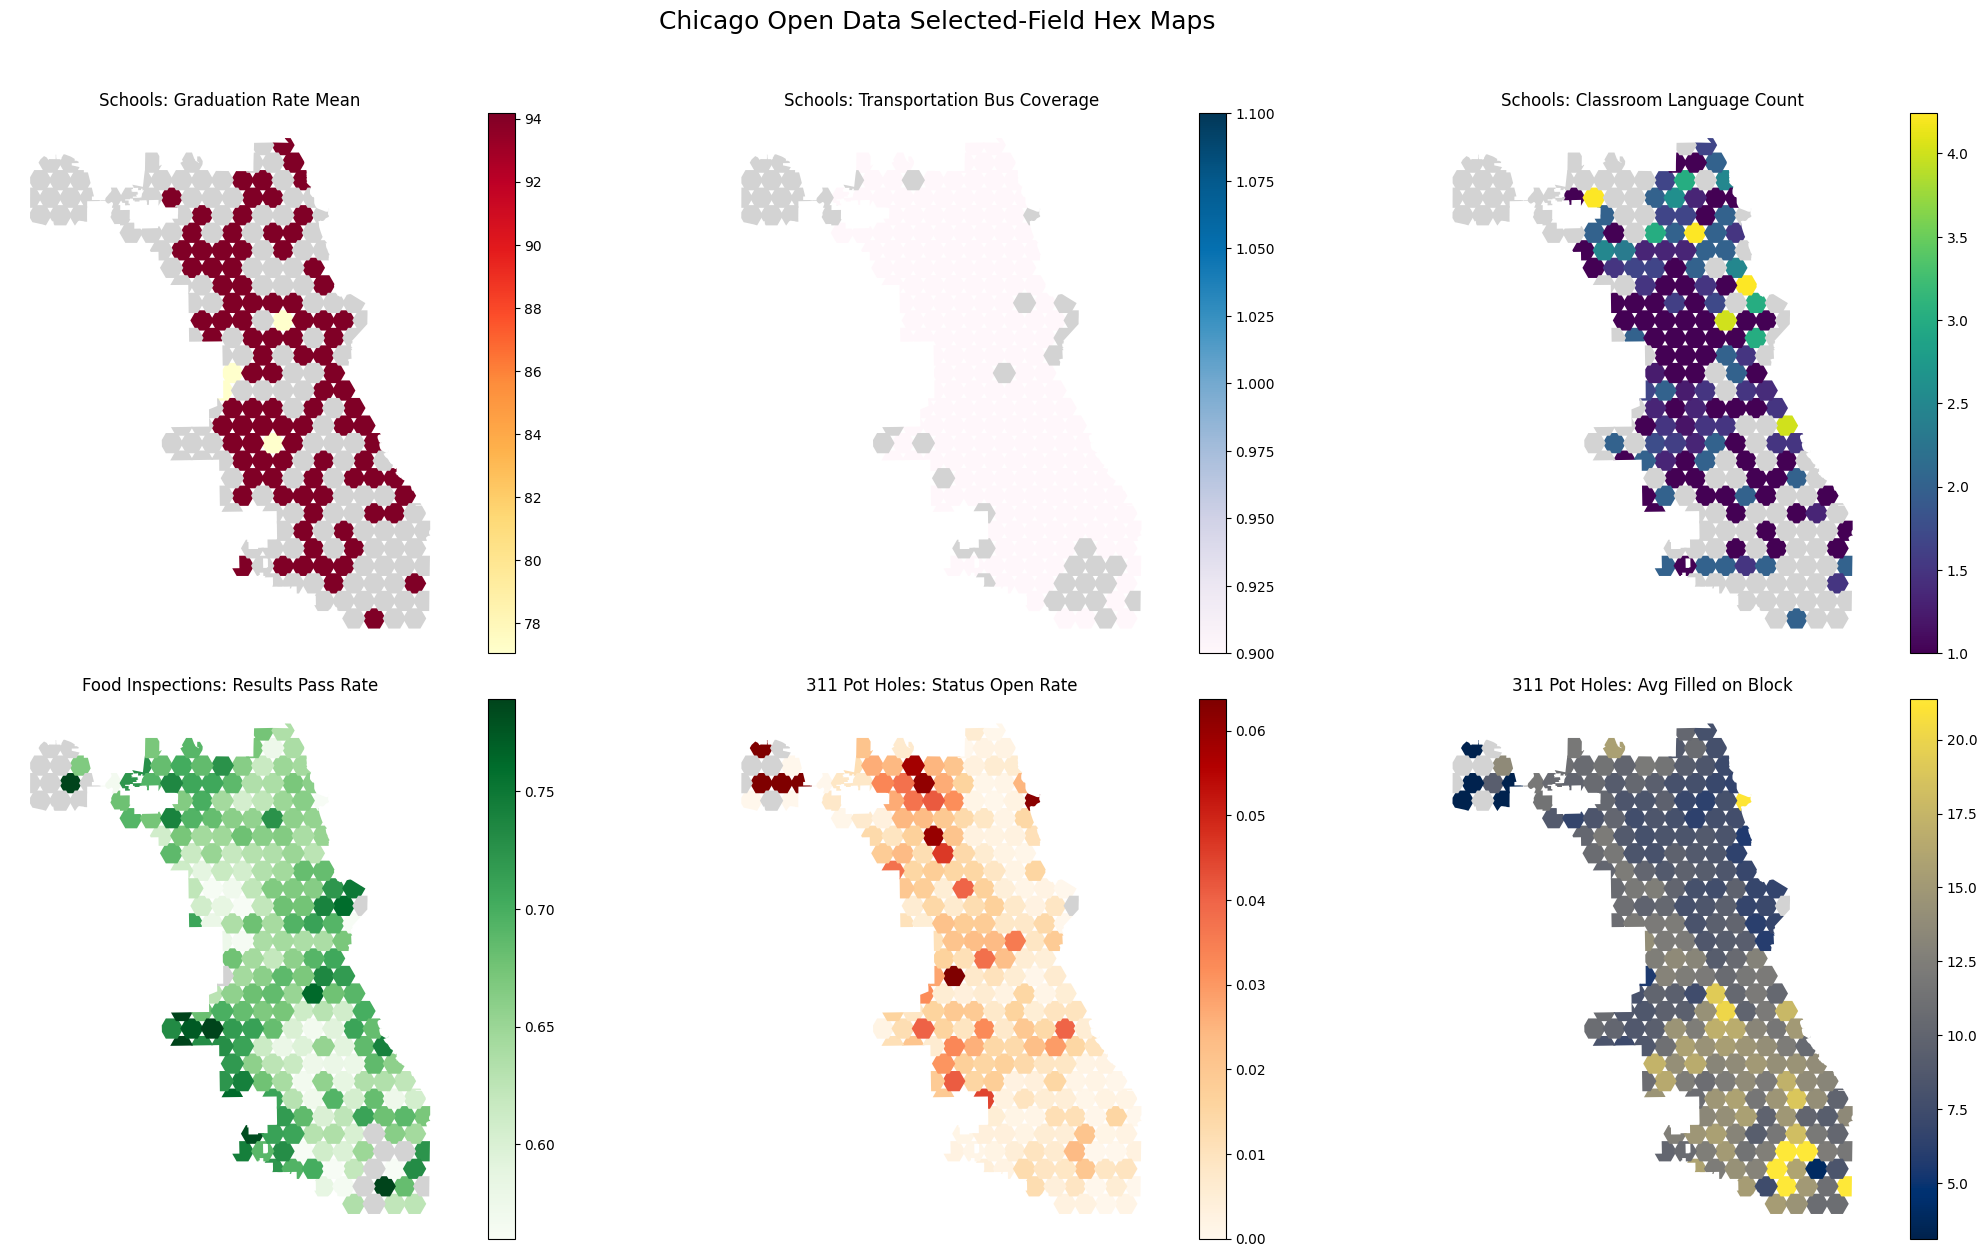

Hex coverage summary:


,hexes_with_values
schools_grad_rate_mean,101
schools_bus_coverage,200
schools_language_count_mean,143
food_pass_rate,224
pothole_open_rate,237
potholes_filled_mean,237


In [41]:
# Build hex-level maps for selected Chicago Open Data fields
import time

open_data_client = Socrata("data.cityofchicago.org", None)

SCHOOLS_ID = "3dhs-m3w4"
FOOD_ID = "4ijn-s7e5"
POTHOLES_ID = "7as2-ds3y"


def _client_get_retry(dataset_id, limit, offset, retries=4, base_sleep=1.0):
    last_err = None
    for attempt in range(retries):
        try:
            return open_data_client.get(dataset_id, limit=limit, offset=offset)
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(base_sleep * (attempt + 1))
    raise last_err


def _fetch_socrata_all(dataset_id, limit=50000, max_pages=20, sleep_s=0.35):
    rows = []
    for page in range(max_pages):
        offset = page * limit
        batch = _client_get_retry(dataset_id, limit=limit, offset=offset)
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < limit:
            break
        time.sleep(sleep_s)
    return pd.DataFrame.from_records(rows)


def _safe_fetch(name, dataset_id):
    try:
        df_local = _fetch_socrata_all(dataset_id)
        print(f"{name}: fetched {len(df_local):,} rows")
        return df_local
    except Exception as e:
        print(f"{name}: fetch failed ({e})")
        return pd.DataFrame()


def _draw_no_data_panel(ax, title):
    hex_gdf.boundary.plot(ax=ax, color="lightgray", linewidth=0.4)
    ax.set_title(f"{title} (No data)")
    ax.set_axis_off()


# --- 1) Schools ---
schools_raw = _safe_fetch("Schools", SCHOOLS_ID)
schools_hex = pd.DataFrame(columns=["hex_id", "schools_grad_rate_mean", "schools_bus_coverage", "schools_language_count_mean", "schools_n"])
if not schools_raw.empty:
    schools_raw["school_latitude"] = pd.to_numeric(schools_raw.get("school_latitude"), errors="coerce")
    schools_raw["school_longitude"] = pd.to_numeric(schools_raw.get("school_longitude"), errors="coerce")
    schools_raw["graduation_rate_mean"] = pd.to_numeric(schools_raw.get("graduation_rate_mean"), errors="coerce")

    # Presence of any bus-route text as service-coverage proxy.
    schools_raw["transportation_bus"] = schools_raw.get("transportation_bus", "").astype(str)
    schools_raw["has_transport_bus"] = schools_raw["transportation_bus"].str.strip().ne("")

    # Number of listed classroom languages as diversity proxy.
    schools_raw["classroom_languages"] = schools_raw.get("classroom_languages", "").astype(str)
    schools_raw["classroom_language_count"] = (
        schools_raw["classroom_languages"]
        .str.split(",")
        .apply(lambda x: len([v for v in x if str(v).strip() != ""]) if isinstance(x, list) else np.nan)
    )

    schools_raw = schools_raw.dropna(subset=["school_latitude", "school_longitude"]).copy()

    if not schools_raw.empty:
        schools_pts = gpd.GeoDataFrame(
            schools_raw,
            geometry=gpd.points_from_xy(schools_raw["school_longitude"], schools_raw["school_latitude"]),
            crs="EPSG:4326",
        ).to_crs(hex_gdf.crs)

        schools_join = gpd.sjoin(schools_pts, hex_gdf[["hex_id", "geometry"]], how="inner", predicate="within")
        schools_hex = (
            schools_join.groupby("hex_id", as_index=False)
            .agg(
                schools_grad_rate_mean=("graduation_rate_mean", "mean"),
                schools_bus_coverage=("has_transport_bus", "mean"),
                schools_language_count_mean=("classroom_language_count", "mean"),
                schools_n=("has_transport_bus", "size"),
            )
        )

# --- 2) Food Inspections ---
food_raw = _safe_fetch("Food Inspections", FOOD_ID)
food_hex = pd.DataFrame(columns=["hex_id", "food_pass_rate", "food_fail_rate", "food_n"])
if not food_raw.empty:
    food_raw["latitude"] = pd.to_numeric(food_raw.get("latitude"), errors="coerce")
    food_raw["longitude"] = pd.to_numeric(food_raw.get("longitude"), errors="coerce")
    food_raw["results"] = food_raw.get("results", "").astype(str).str.lower()

    food_raw["is_pass"] = food_raw["results"].str.contains("pass", na=False)
    food_raw["is_fail"] = food_raw["results"].str.contains("fail", na=False)

    food_raw = food_raw.dropna(subset=["latitude", "longitude"]).copy()

    if not food_raw.empty:
        food_pts = gpd.GeoDataFrame(
            food_raw,
            geometry=gpd.points_from_xy(food_raw["longitude"], food_raw["latitude"]),
            crs="EPSG:4326",
        ).to_crs(hex_gdf.crs)

        food_join = gpd.sjoin(food_pts, hex_gdf[["hex_id", "geometry"]], how="inner", predicate="within")
        food_hex = (
            food_join.groupby("hex_id", as_index=False)
            .agg(
                food_pass_rate=("is_pass", "mean"),
                food_fail_rate=("is_fail", "mean"),
                food_n=("is_pass", "size"),
            )
        )

# --- 3) Pot Holes ---
pot_raw = _safe_fetch("311 Pot Holes", POTHOLES_ID)
pot_hex = pd.DataFrame(columns=["hex_id", "pothole_open_rate", "potholes_filled_mean", "pothole_n"])
if not pot_raw.empty:
    pot_raw["latitude"] = pd.to_numeric(pot_raw.get("latitude"), errors="coerce")
    pot_raw["longitude"] = pd.to_numeric(pot_raw.get("longitude"), errors="coerce")
    pot_raw["status"] = pot_raw.get("status", "").astype(str).str.lower()
    pot_raw["number_of_potholes_filled_on_block"] = pd.to_numeric(
        pot_raw.get("number_of_potholes_filled_on_block"), errors="coerce"
    )

    pot_raw["is_open"] = pot_raw["status"].str.contains("open", na=False)

    pot_raw = pot_raw.dropna(subset=["latitude", "longitude"]).copy()

    if not pot_raw.empty:
        pot_pts = gpd.GeoDataFrame(
            pot_raw,
            geometry=gpd.points_from_xy(pot_raw["longitude"], pot_raw["latitude"]),
            crs="EPSG:4326",
        ).to_crs(hex_gdf.crs)

        pot_join = gpd.sjoin(pot_pts, hex_gdf[["hex_id", "geometry"]], how="inner", predicate="within")
        pot_hex = (
            pot_join.groupby("hex_id", as_index=False)
            .agg(
                pothole_open_rate=("is_open", "mean"),
                potholes_filled_mean=("number_of_potholes_filled_on_block", "mean"),
                pothole_n=("is_open", "size"),
            )
        )

# Merge all new open-data hex metrics
open_data_hex_compare = (
    hex_gdf[["hex_id", "geometry"]]
    .merge(schools_hex, on="hex_id", how="left")
    .merge(food_hex, on="hex_id", how="left")
    .merge(pot_hex, on="hex_id", how="left")
)

# Plot requested field-driven hex maps
plot_specs = [
    ("schools_grad_rate_mean", "Schools: Graduation Rate Mean", "YlOrRd"),
    ("schools_bus_coverage", "Schools: Transportation Bus Coverage", "PuBu"),
    ("schools_language_count_mean", "Schools: Classroom Language Count", "viridis"),
    ("food_pass_rate", "Food Inspections: Results Pass Rate", "Greens"),
    ("pothole_open_rate", "311 Pot Holes: Status Open Rate", "OrRd"),
    ("potholes_filled_mean", "311 Pot Holes: Avg Filled on Block", "cividis"),
]

ncols = 3
nrows = int(np.ceil(len(plot_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 6.2 * nrows))
axes = np.array(axes).reshape(-1)

for i, (col, title, cmap) in enumerate(plot_specs):
    ax = axes[i]
    s = pd.to_numeric(open_data_hex_compare[col], errors="coerce")
    if s.notna().sum() == 0:
        _draw_no_data_panel(ax, title)
        continue

    if s.notna().sum() > 10:
        vmin = s.quantile(0.02)
        vmax = s.quantile(0.98)
        if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
            vmin, vmax = None, None
    else:
        vmin, vmax = None, None

    open_data_hex_compare.plot(
        column=col,
        cmap=cmap,
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    ax.set_title(title)
    ax.set_axis_off()

for j in range(len(plot_specs), len(axes)):
    axes[j].axis("off")

plt.suptitle("Chicago Open Data Selected-Field Hex Maps", y=1.01, fontsize=18)
plt.tight_layout()
plt.show()

print("Hex coverage summary:")
coverage_cols = [c for c, _, _ in plot_specs]
display(open_data_hex_compare[coverage_cols].notna().sum().rename("hexes_with_values").to_frame())